# Python Analysis -- Food Environment Index at the State and County Level


### Load the necessary libraries

In [59]:
#Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

### Import the datasets

In [60]:
county_lvl = pd.read_csv('2025_CHR_county.csv')

state_lvl = pd.read_csv('2025_CHR_state.csv')

### Inspect the datasets

In [61]:
#county level data shape
county_lvl.shape

(3159, 33)

In [62]:
#state level data shape
state_lvl.shape

(51, 26)

In [63]:
#column names -- county
county_lvl.columns.tolist()


['State',
 'County',
 'Deaths',
 'Food Environment Index',
 'National Z-Score',
 '% Children in Poverty',
 '95% CI - Low',
 '95% CI - High',
 'National Z-Score.1',
 '% Children in Poverty (AIAN)',
 '% Children in Poverty (Asian)',
 '% Children in Poverty (Black)',
 '% Children in Poverty (Hispanic)',
 '% Children in Poverty (White)',
 '% Adults with Diabetes',
 '95% CI - Low.1',
 '95% CI - High.1',
 '% Adults with Obesity',
 '95% CI - Low.2',
 '95% CI - High.2',
 '# Limited Access to Healthy Foods',
 '% Limited Access to Healthy Foods',
 '# Food Insecure',
 '% Food Insecure',
 'Segregation Index',
 'Population',
 'Population Size',
 'Unnamed: 27',
 'Unnamed: 28',
 'Unnamed: 29',
 'Unnamed: 30',
 'Population.1',
 'Unnamed: 32']

In [64]:
# remove unnamed and extra columns from county level data
county_lvl = county_lvl.loc[:, ~county_lvl.columns.str.contains('^Unnamed')]
county_lvl = county_lvl.drop(columns = ['Population.1'])
county_lvl = county_lvl.drop(columns = ['National Z-Score',
'95% CI - Low',
 '95% CI - High',
 'National Z-Score.1',
 '% Children in Poverty (AIAN)',
 '% Children in Poverty (Asian)',
 '% Children in Poverty (Black)',
 '% Children in Poverty (Hispanic)',
 '% Children in Poverty (White)',
 '95% CI - Low.1',
 '95% CI - High.1',
 '95% CI - Low.2',
 '95% CI - High.2'])

In [65]:
#column names -- state
state_lvl.columns


Index(['State', 'County', 'Deaths', 'Food Environment Index',
       'National Z-Score', '% Children in Poverty', '95% CI - Low',
       '95% CI - High', 'National Z-Score.1', '% Children in Poverty (AIAN)',
       '% Children in Poverty (Asian)', '% Children in Poverty (Black)',
       '% Children in Poverty (Hispanic)', '% Children in Poverty (White)',
       '% Adults with Diabetes', '95% CI - Low.1', '95% CI - High.1',
       '% Adults with Obesity', '95% CI - Low.2', '95% CI - High.2',
       '# Limited Access to Healthy Foods',
       '% Limited Access to Healthy Foods', '# Food Insecure',
       '% Food Insecure', 'Segregation Index', 'Population'],
      dtype='object')

In [66]:
# drop unnnecessary columns from state level data
state_lvl = state_lvl.drop(columns = ['National Z-Score',
'95% CI - Low',
 '95% CI - High',
 'National Z-Score.1',
 '% Children in Poverty (AIAN)',
 '% Children in Poverty (Asian)',
 '% Children in Poverty (Black)',
 '% Children in Poverty (Hispanic)',
 '% Children in Poverty (White)',
 '95% CI - Low.1',
 '95% CI - High.1',
 '95% CI - Low.2',
 '95% CI - High.2'])

### Examine first and last 5 rows of each dataset

In [67]:
#First 5 rows of state level data
state_lvl.head()

,State,County,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population
0,Alabama,NaN,102760,5.3,21,14,38,418731,9,884270,17,58,5108468
1,Alaska,NaN,10540,7.1,13,8,32,55887,8,93620,13,57,733406
2,Arizona,NaN,111570,6.8,16,11,34,554825,9,963130,13,51,7431344
3,Arkansas,NaN,59089,4.4,20,14,38,292058,10,567110,19,65,3067732
4,California,NaN,442212,8.7,15,11,28,1204935,3,4915450,13,59,38965193


In [68]:
#First 5 rows of county level data
county_lvl.head()

,State,County,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population,Population Size
0,Alabama,Bullock,251.0,4.4,40.0,20.0,49.0,3529.0,32.0,1750.0,17.0,34.0,9897.0,Small
1,Alabama,Perry,249.0,3.9,50.0,19.0,50.0,2949.0,28.0,1820.0,21.0,61.0,7738.0,Small
2,Alabama,Wilcox,301.0,4.7,49.0,19.0,49.0,2764.0,24.0,2070.0,20.0,35.0,9944.0,Small
3,Alabama,Greene,237.0,4.5,47.0,19.0,51.0,2058.0,23.0,1630.0,21.0,27.0,7341.0,Small
4,Alabama,Macon,476.0,5.6,41.0,18.0,48.0,4741.0,22.0,3170.0,17.0,54.0,18370.0,Small


In [69]:
#last 5 rows of state level data
state_lvl.tail()

,State,County,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population
46,Virginia,NaN,116521,8.8,13,11,35,355070,4,963980,11,51,8715698
47,Washington,NaN,92250,8.5,12,9,32,341332,5,891960,12,60,7812880
48,West Virginia,NaN,42671,6.5,20,14,42,139050,8,266370,15,61,1770071
49,Wisconsin,NaN,78299,8.8,13,9,38,284381,5,617790,11,77,5910955
50,Wyoming,NaN,9112,6.5,12,8,35,44840,8,83780,14,71,584057


In [70]:
#last 5 rows of county level data
county_lvl.tail()

,State,County,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population,Population Size
3154,Wyoming,Teton,123.0,8.7,6.0,7.0,22.0,812.0,4.0,2600.0,11.0,NaN,23232.0,Small
3155,Wyoming,Washakie,130.0,8.3,17.0,9.0,39.0,262.0,3.0,1020.0,13.0,NaN,7710.0,Small
3156,Wyoming,Converse,203.0,8.2,13.0,9.0,37.0,398.0,3.0,1910.0,14.0,NaN,13809.0,Small
3157,Wyoming,Hot Springs,118.0,7.6,16.0,10.0,39.0,114.0,2.0,770.0,17.0,NaN,4661.0,Small
3158,Wyoming,Uinta,339.0,8.5,11.0,9.0,36.0,290.0,1.0,2700.0,13.0,NaN,20745.0,Small


### Check data types and number of missing values

In [71]:
# state level data types
state_lvl.dtypes

State                                 object
County                               float64
Deaths                                 int64
Food Environment Index               float64
% Children in Poverty                  int64
% Adults with Diabetes                 int64
% Adults with Obesity                  int64
# Limited Access to Healthy Foods      int64
% Limited Access to Healthy Foods      int64
# Food Insecure                        int64
% Food Insecure                        int64
Segregation Index                      int64
Population                             int64
dtype: object

In [72]:
# county level data types
county_lvl.dtypes

State                                 object
County                                object
Deaths                               float64
Food Environment Index               float64
% Children in Poverty                float64
% Adults with Diabetes               float64
% Adults with Obesity                float64
# Limited Access to Healthy Foods    float64
% Limited Access to Healthy Foods    float64
# Food Insecure                      float64
% Food Insecure                      float64
Segregation Index                    float64
Population                           float64
Population Size                       object
dtype: object

In [73]:
#state level missing values -- only county is missing because it is not applicable to state level data
state_lvl.isnull().sum()

State                                 0
County                               51
Deaths                                0
Food Environment Index                0
% Children in Poverty                 0
% Adults with Diabetes                0
% Adults with Obesity                 0
# Limited Access to Healthy Foods     0
% Limited Access to Healthy Foods     0
# Food Insecure                       0
% Food Insecure                       0
Segregation Index                     0
Population                            0
dtype: int64

In [74]:
#County level missing values -- note that there are several columns with missing values compared to state level data
county_lvl.isnull().sum()

State                                   0
County                                  0
Deaths                                254
Food Environment Index                 59
% Children in Poverty                  16
% Adults with Diabetes                 15
% Adults with Obesity                  15
# Limited Access to Healthy Foods      51
% Limited Access to Healthy Foods      51
# Food Insecure                        15
% Food Insecure                        15
Segregation Index                    1095
Population                             15
Population Size                         0
dtype: int64

### Descriptive statistics

In [75]:
# county level
county_lvl.describe()

,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population
count,2905.000000,3100.000000,3143.000000,3144.000000,3144.000000,3108.000000,3108.000000,3.144000e+03,3144.000000,2064.000000,3.144000e+03
mean,1636.750086,7.453097,19.040407,11.184160,37.960242,6059.545689,8.526062,1.356732e+04,14.459606,49.515988,1.065251e+05
std,4248.984528,1.199685,8.057714,2.328999,4.654600,14262.033531,7.424394,4.328182e+04,3.480543,16.637061,3.325717e+05
min,50.000000,0.000000,3.000000,6.000000,18.000000,0.000000,0.000000,1.000000e+01,6.000000,1.000000,4.300000e+01
25%,268.000000,6.800000,13.000000,9.000000,35.000000,591.500000,4.000000,1.610000e+03,12.000000,38.000000,1.075625e+04
50%,568.000000,7.600000,18.000000,11.000000,38.000000,1739.500000,7.000000,3.870000e+03,14.000000,50.000000,2.596850e+04
75%,1352.000000,8.300000,23.000000,13.000000,41.000000,5204.250000,11.000000,9.862500e+03,17.000000,61.000000,6.952050e+04
max,111660.000000,10.000000,63.000000,22.000000,53.000000,236351.000000,63.000000,1.314070e+06,29.000000,92.000000,9.663345e+06


In [76]:
#state level
state_lvl.describe()

,County,Deaths,Food Environment Index,% Children in Poverty,% Adults with Diabetes,% Adults with Obesity,# Limited Access to Healthy Foods,% Limited Access to Healthy Foods,# Food Insecure,% Food Insecure,Segregation Index,Population
count,0.0,51.000000,51.000000,51.000000,51.000000,51.000000,5.100000e+01,51.000000,5.100000e+01,51.000000,51.000000,5.100000e+01
mean,NaN,93411.549020,7.437255,15.333333,10.294118,34.098039,3.692959e+05,6.588235,8.691747e+05,13.117647,62.843137,6.566959e+06
std,NaN,94679.403641,1.379269,4.048045,1.814322,4.124342,3.879281e+05,2.450930,1.026704e+06,2.214923,8.063182,7.460690e+06
min,NaN,8599.000000,3.900000,8.000000,7.000000,25.000000,9.664000e+03,2.000000,6.631000e+04,9.000000,45.000000,5.840570e+05
25%,NaN,23478.000000,6.550000,13.000000,9.000000,31.500000,1.136685e+05,5.000000,2.436800e+05,12.000000,57.000000,1.867398e+06
50%,NaN,68290.000000,7.600000,15.000000,10.000000,34.000000,2.774730e+05,6.000000,6.177900e+05,13.000000,63.000000,4.526154e+06
75%,NaN,112084.000000,8.600000,18.500000,11.000000,37.500000,4.727200e+05,8.000000,9.635550e+05,14.000000,69.000000,7.622112e+06
max,NaN,442212.000000,9.400000,25.000000,14.000000,42.000000,2.099608e+06,13.000000,4.919210e+06,19.000000,80.000000,3.896519e+07


# Visualizations

### Create a dataset for each of the states of interest (Mississippi and New Hampshire)

In [77]:
#county level data for Mississippi
ms = county_lvl[county_lvl['State'] == 'Mississippi']

In [78]:
#county level data for New Hampshire
nh = county_lvl[county_lvl['State'] == 'New Hampshire']

## Distribution of variables of interest in the two states

### Diabetes rates 
#### New Hampshire

<Axes: title={'center': 'Distribution of % Adults with Diabetes in New Hampshire'}, ylabel='Frequency'>

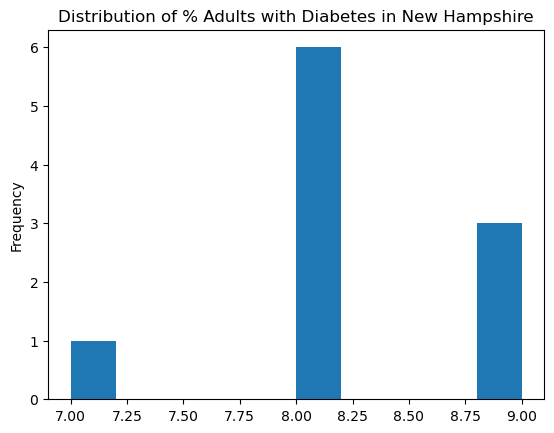

In [90]:
nh['% Adults with Diabetes'].plot(kind = 'hist', title = 'Distribution of % Adults with Diabetes in New Hampshire', bins = 10)

#### Mississippi

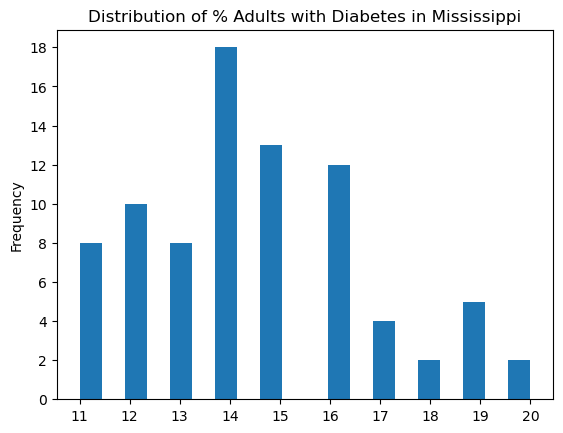

In [103]:
ms['% Adults with Diabetes'].plot(kind = 'hist', title = 'Distribution of % Adults with Diabetes in Mississippi', bins = 20)
plt.locator_params(axis='y', nbins=10)
plt.locator_params(axis='x', nbins=10)

### Obesity Rates
#### New Hampshire

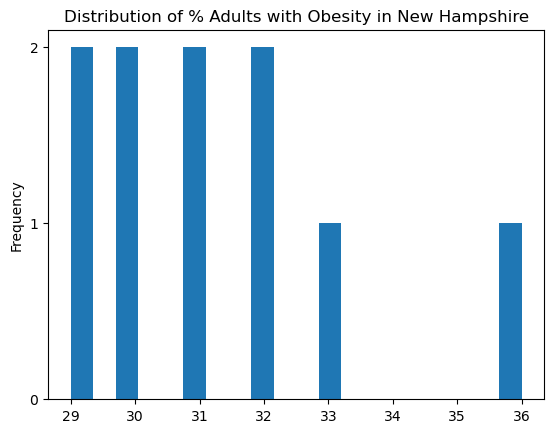

In [95]:
nh['% Adults with Obesity'].plot(kind = 'hist', title = 'Distribution of % Adults with Obesity in New Hampshire', bins = 20)
plt.locator_params(axis='y', nbins=4)


<Axes: title={'center': 'Distribution of % Adults with Obesity in Mississippi'}, ylabel='Frequency'>

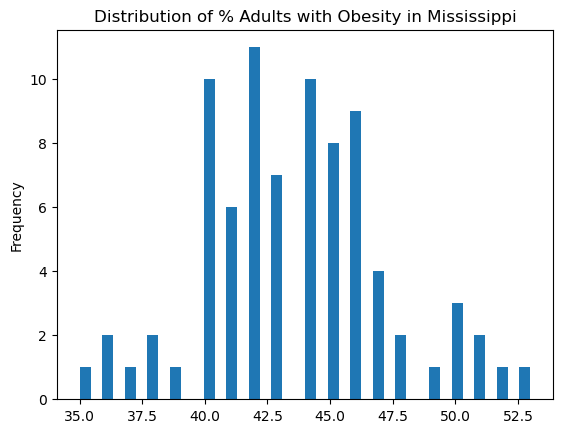

In [102]:
ms['% Adults with Obesity'].plot(kind = 'hist', title = 'Distribution of % Adults with Obesity in Mississippi', bins = 40)

## Scatter plots of food environment vs diabetes and obesity rates in key states

<Axes: title={'center': 'Food Environment Index vs % Adults with Obesity in New Hampshire'}, xlabel='Food Environment Index', ylabel='% Adults with Obesity'>

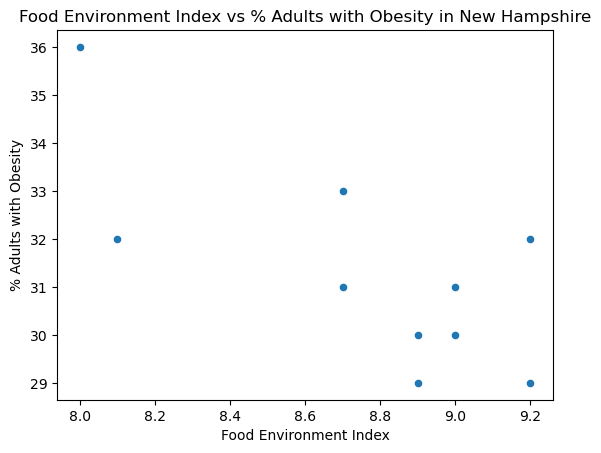

In [112]:
nh.plot(kind = 'scatter', x = 'Food Environment Index', y = '% Adults with Obesity', title = 'Food Environment Index vs % Adults with Obesity in New Hampshire')

<Axes: title={'center': 'Food Environment Index vs % Adults with Obesity in Mississippi'}, xlabel='Food Environment Index', ylabel='% Adults with Obesity'>

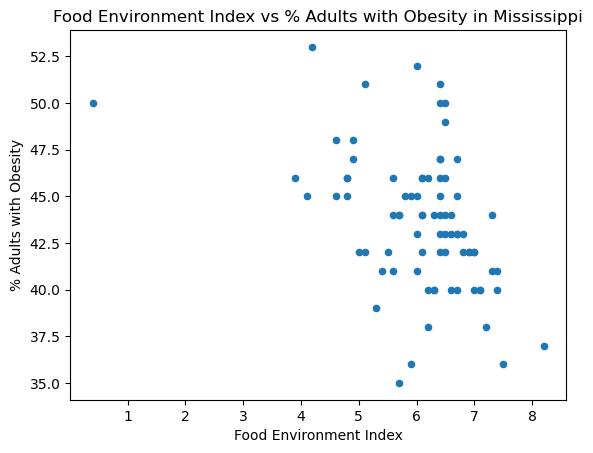

In [111]:
ms.plot(kind = 'scatter', x = 'Food Environment Index', y = '% Adults with Obesity', title = 'Food Environment Index vs % Adults with Obesity in Mississippi')

<Axes: title={'center': 'Food Environment Index vs % Adults with Diabetes in New Hampshire'}, xlabel='Food Environment Index', ylabel='% Adults with Diabetes'>

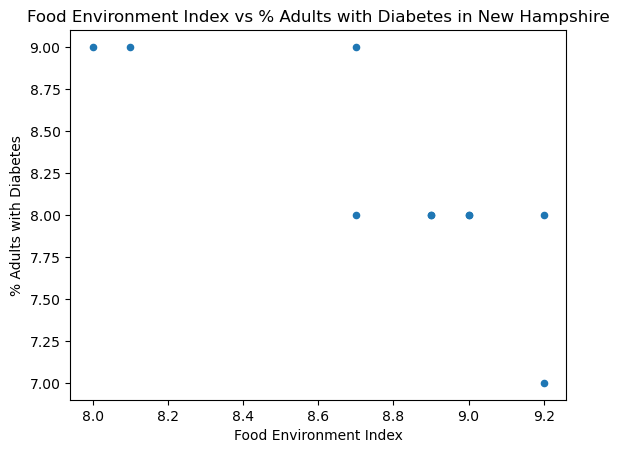

In [81]:
nh.plot(kind = 'scatter', x = 'Food Environment Index', y = '% Adults with Diabetes', title = 'Food Environment Index vs % Adults with Diabetes in New Hampshire')

<Axes: title={'center': 'Food Environment Index vs % Adults with Diabetes in Mississippi'}, xlabel='Food Environment Index', ylabel='% Adults with Diabetes'>

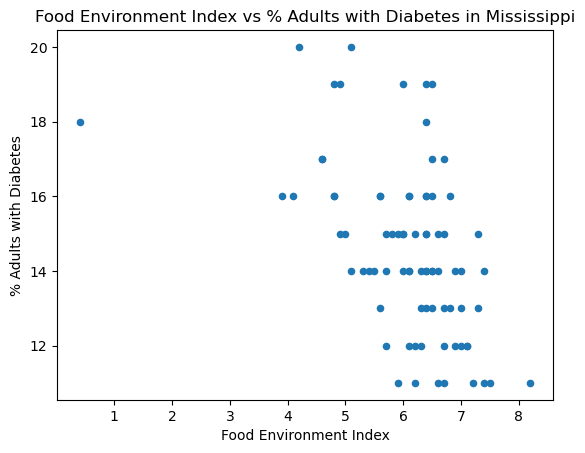

In [83]:
ms.plot(kind = 'scatter', x = 'Food Environment Index', y = '% Adults with Diabetes', title = 'Food Environment Index vs % Adults with Diabetes in Mississippi')


### Bar plots of other variables of interest vs food environment index

### Food environment index vs # children in poverty

<Axes: title={'center': 'Food Environment Index vs % Children in Poverty in New Hampshire'}, xlabel='Food Environment Index'>

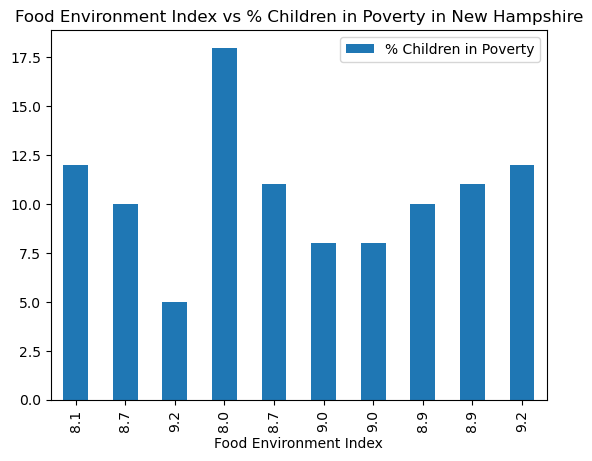

In [113]:
nh.plot(kind = 'bar', x = 'Food Environment Index', y = '% Children in Poverty', title = 'Food Environment Index vs % Children in Poverty in New Hampshire')

/var/folders/01/lw73l0r90gz16dc6pgf3v3zm0000gn/T/ipykernel_5126/3157030083.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = ms_grouped.groupby("fei_category")[["% Children in Poverty", "Segregation Index"]].mean().reset_index()


Text(0, 0.5, '% Children in Poverty')

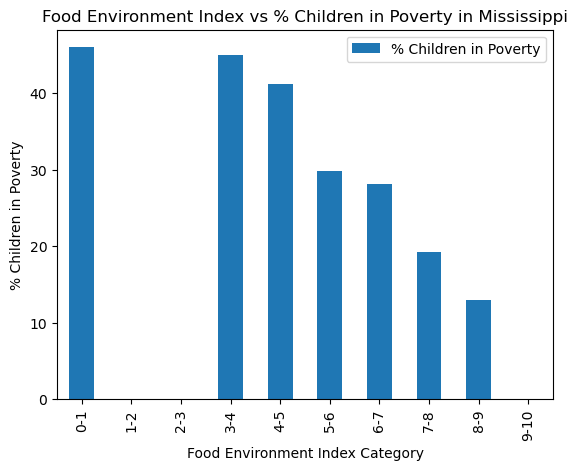

In [132]:
ms_grouped = ms.copy()
ms_grouped["fei_category"] = pd.cut(
    ms_grouped["Food Environment Index"],
    bins=[0,1,2,3,4,5,6,7,8,9,10],
    labels=["0-1","1-2","2-3","3-4","4-5","5-6","6-7","7-8","8-9","9-10"]
)

summary = ms_grouped.groupby("fei_category")[["% Children in Poverty", "Segregation Index"]].mean().reset_index()

summary.plot(kind='bar', x='fei_category', y='% Children in Poverty',
             title='Food Environment Index vs % Children in Poverty in Mississippi')
plt.xlabel('Food Environment Index Category')
plt.ylabel('% Children in Poverty')


### 

<Axes: title={'center': 'Food Environment Index vs Segregation Index in New Hampshire'}, xlabel='Food Environment Index'>

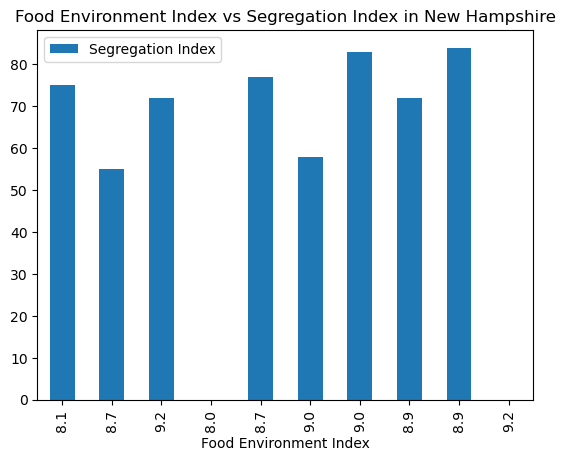

In [128]:
nh.plot(kind = 'bar', x = 'Food Environment Index', y = 'Segregation Index', title = 'Food Environment Index vs Segregation Index in New Hampshire')

Text(0, 0.5, 'Segregation Index')

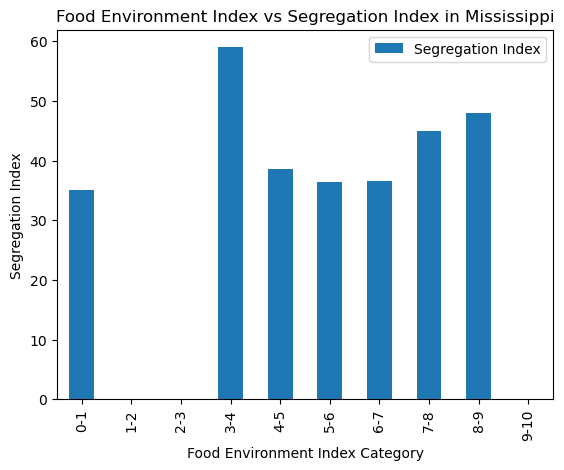

In [133]:
summary.plot(kind='bar', x='fei_category', y='Segregation Index',
             title='Food Environment Index vs Segregation Index in Mississippi')
plt.xlabel('Food Environment Index Category')
plt.ylabel('Segregation Index')
